# **Autoencoders**

This notebook serves as a foundational baseline implementation of a Autoencoder created during advanced deep learning coursework to benchmark core computer vision structures.


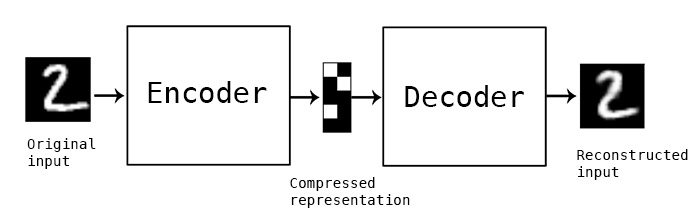

### **Let's build the simplest autoencoder to reconstruct MNIST images**
*  We define a class AE to be general enough to work on different input, output, and encoding sizes
*  a single fully-connected neural layer as encoder and as decoder

*  **Activation function:** for the last layer depends on the input data:
>  if they are in [0,1] --> sigmoid
>  if they are in [-1,1] --> tanh
>  if they are in other ranges ---> linear, ReLU etc.
*  **LOSS**: for this application, with grayscale images, we use a MSE loss with sigmoid activation

In [ ]:
import tensorflow.keras as K
from tensorflow.keras import layers

# one Fully-Connected layer encoder
# ENCODING_DIM: This is the size of our encoded representations
def enc(INPUT_SHAPE, ENCODING_DIM):
    return K.Sequential([
            layers.Input(shape=(INPUT_SHAPE,)),
            ### here can add other hidden layers
            layers.Dense(ENCODING_DIM, activation='relu')
    ])


def dec(OUTPUT_SHAPE, ENCODING_DIM, out_activation='sigmoid'):
    return K.Sequential([
        # here can add other hidden layers
        layers.Dense(OUTPUT_SHAPE, input_shape=(ENCODING_DIM,),
                          activation=out_activation)
    ])

class AE(K.Model):
  def __init__(self, INPUT_SHAPE, ENCODING_DIM,
               enc_model, dec_model, out_activation='sigmoid'):
    super(AE, self).__init__()
    #############################################
    #----------ENCODER--------------------------#
    # input here 784-dimensional
    self.encoder = enc_model(INPUT_SHAPE,ENCODING_DIM)
    # output here 32-dimensional
    #############################################
    #----------DECODER--------------------------#
    # input here 32-dimensional
    self.decoder = dec_model(INPUT_SHAPE, ENCODING_DIM, out_activation)

# method to encode images
  def getEncodedImage(self, image):
        encoded_image = self.encoder.predict(image)
        return encoded_image
# method to decode images
  def getDecodedImage(self, encoded_imgs):
      decoded_image = self.decoder.predict(encoded_imgs)
      return decoded_image

  def call(self, input):
    out_encoder = self.encoder(input)
    out_decoder = self.decoder(out_encoder)
    return out_decoder




# **Now let's train the autoencoder to reconstruct MNIST digit**

* ## Since we use a MLP, we need to vectorize the input
* ## First, we configure our model to use a per-pixel binary crossentropy loss
* ## We normalize all pixel values between 0 and 1 and flatten the 28x28 images into vectors of size 784.
* ## Being images and output in [0,1], we can use both mse and binary_crossentropy as loss function




In [2]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)
# normalizing
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
# MLP receives vectors as inputs
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 784)
(10000, 784)


# **Creating the model**
* ## We use an undercomplete autoencoder
* ## Using an embedding dimension 32, we get a compression of factor 24.5%, assuming the input is 784
* ## ## **Be aware**: We use the test data without extracting a validation set because we are not performing any model selection

In [4]:
# This is the size of our encoded representations
ENCODING_DIM = 32
input_shape = x_train.shape[1] # mnist flatten img

autoenc = AE(input_shape,
                  ENCODING_DIM,
                  enc,
                  dec,
                  out_activation='sigmoid')

lr = 10**-3
autoenc.compile(optimizer=K.optimizers.Adam(learning_rate=lr),
                loss='mse')
                #loss='binary_crossentropy')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
epochs = 50
batch_size=256
autoenc.fit(x_train, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1083 - val_loss: 0.0402
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0372 - val_loss: 0.0291
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0279 - val_loss: 0.0232
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0225 - val_loss: 0.0193
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0189 - val_loss: 0.0161
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0160 - val_loss: 0.0141
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0141 - val_loss: 0.0127
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0128 - val_loss: 0.0118
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0112
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0115 - val_loss: 0.0108
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0111 - val_loss: 0.0105
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

# **After 50 epochs, the autoencoder seems to reach a stable train/validation loss value of about 0.09**
* ## We can try to visualize the reconstructed inputs and the encoded representations. We will use Matplotlib.

In [6]:
# Encode and decode test digits, then print some
encoded_imgs = autoenc.getEncodedImage(x_test)
print(f"encoded images shape:{encoded_imgs.shape}, encoded_imgs[0:2]:{encoded_imgs[0:2]}")
decoded_imgs = autoenc.getDecodedImage(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
encoded images shape:(10000, 32), encoded_imgs[0:2]:[[ 8.105252    2.2380643   3.7925591   2.3182049   7.4195614   6.682575
   2.1902645   4.042821    4.6471543  10.847882    2.0578249   7.830474
   7.067148    4.0574884   4.392664    5.0706873   6.4624844   2.832168
   2.9416432   0.          7.154476    5.243436    3.2611606   8.227585
   5.732645    7.474931   13.671581   11.250652    4.2194805   8.031154
   6.521759    1.6540632 ]
 [ 8.367856    6.462414   13.51883     8.253117    8.2025585   7.0822434
  10.814819    1.9505192   0.09006941  0.9697263   9.614289    8.077282
  13.446482    5.049835    4.541858    9.088061    9.739858    6.3039265
   4.4964876  23.403955   10.136365    9.199462    7.7966833   9.910014
   5.055321    7.1308656   4.792423    6.2467613   7.1106706  21.184366
   4.3203087  11.382745  ]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


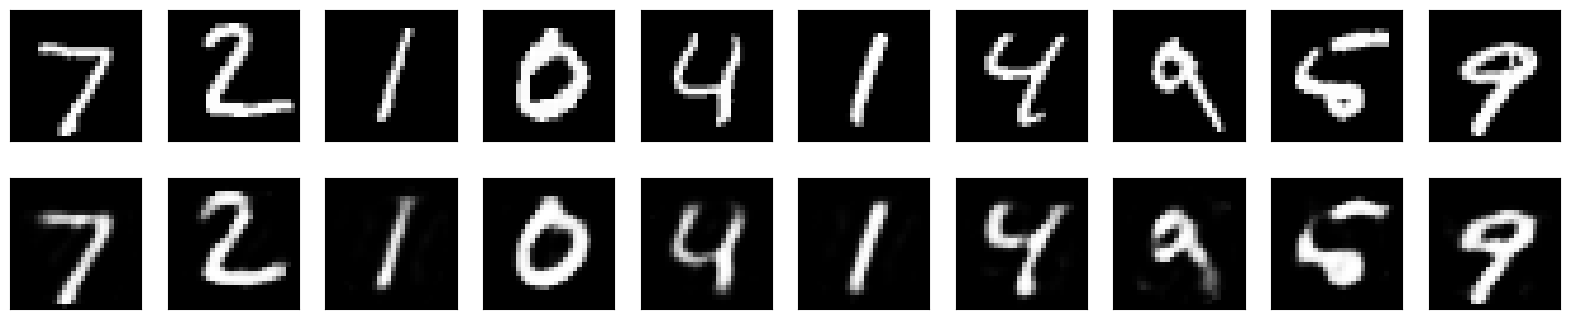

In [7]:

import matplotlib.pyplot as plt

def plot_imgs(original, decoded_imgs, n=10):
  # n  How many digits we will display
  plt.figure(figsize=(20, 4))
  for i in range(n):
      # Display original
      ax = plt.subplot(2, n, i + 1)
      plt.imshow(original[i].reshape(28, 28))
      plt.gray()
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)

      # Display reconstruction
      ax = plt.subplot(2, n, i + 1 + n)
      plt.imshow(decoded_imgs[i].reshape(28, 28))
      plt.gray()
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
  plt.show()

plot_imgs(x_test, decoded_imgs, n=10)


# **Here's what we get**
* # The top row is the original digits, and the bottom row is the reconstructed digits
* # We are losing some details with this basic approach, although the result is already acceptable

# **Exercise**
* ## Use an autoencoder to learn a compressed representation of one-hot word vectors in the Gutenberg ebook exercise
* ## Then learn recurrent classification model using such the inner representation of the AE as embedding

-------------------------------------------

# **Adding a sparsity constraint on the encoded representations**
 * # So far, the representations were only constrained by the size of the hidden layer ($32$)
 * # Let's add a sparsity contraint on the activity of the hidden representations
* # This can be done via ```activity_regularizer``` argument of ```Dense``` layer, imposing a L1 norm regularization

In [8]:
from tensorflow.keras import regularizers


# one Fully-Connected layer encoder with spersity constraint
# ENCODING_DIM: This is the size of our encoded representations
## Weight: hyperparameter regulating the strenght of the regularization
def sparse_enc(INPUT_SHAPE, ENCODING_DIM, weight=10**-6):
    return K.Sequential([
        layers.Input(shape=(INPUT_SHAPE,)),
            ### here can add other hidden layers
        layers.Dense(ENCODING_DIM,  activation='relu',
                        activity_regularizer=regularizers.l1(weight))
    ])


autoenc_s = AE(input_shape,
                    ENCODING_DIM,
                    sparse_enc,
                    dec,
                    out_activation='sigmoid')

In [9]:
autoenc_s.compile(optimizer=K.optimizers.Adam(learning_rate=lr),
                  #loss='binary_crossentropy')
                  loss='mse')
epochs = 50
batch_size=256
autoenc_s.fit(x_train, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1238 - val_loss: 0.0506
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0472 - val_loss: 0.0393
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0383 - val_loss: 0.0345
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0339 - val_loss: 0.0312
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0309 - val_loss: 0.0285
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0283 - val_loss: 0.0263
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0263 - val_loss: 0.0246
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0247 - val_loss: 0.0234
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0235 - val_loss: 0.0225
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0227 - val_loss: 0.0218
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0220 - val_loss: 0.0212
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

# **After 50 epochs, the autoencoder seems to reach a stable train/validation loss value of about 0.01, slightly higher than before**
* ## Like before, we can try to visualize the reconstructed inputs and the encoded representations.
* ## Moreover, we can also evaluate the effect of spartity regularization by compunting the average magnitude of the activations in the encoded images

In [10]:
# Encode and decode test digits, and print some
encoded_s_imgs = autoenc_s.getEncodedImage(x_test)
print(encoded_s_imgs[0:2])
decoded_s_imgs = autoenc_s.getDecodedImage(encoded_s_imgs)
print(f"sparse autoencoder mean coded value: {encoded_s_imgs.mean()}")
print(f"Vanilla autoencoder mean coded value:  {encoded_imgs.mean()}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[0.4732126  0.67960465 0.14204103 0.9082912  0.8707778  0.1483799
  0.30801225 0.01542771 0.17925608 1.7952234  0.11727585 0.2363088
  0.09026191 0.         0.         0.15021235 0.19927482 0.04029927
  1.047508   0.23778671 0.23221391 0.5736606  1.1593711  0.3729377
  0.5073694  0.5468842  0.13617566 0.34363437 0.16381305 0.
  0.5419426  0.        ]
 [0.4614463  1.3756361  0.02137196 0.75784975 0.20881803 0.96787375
  0.33386034 0.         0.9642194  0.         1.4187157  0.28961548
  0.47824174 1.2827656  0.60387444 0.47105834 0.716782   0.
  0.82107365 0.33543736 1.0883772  0.3836332  0.13406903 0.3174559
  0.5165937  0.45060328 0.         0.         0.18044025 0.22269845
  0.         1.1558431 ]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
sparse autoencoder mean coded value: 0.47275376319885254
Vanilla autoencoder mean coded value:  8.20045280456543


# **The sparse encoder induces representations around 20 times smaller in average magnitude than the dense encoder**


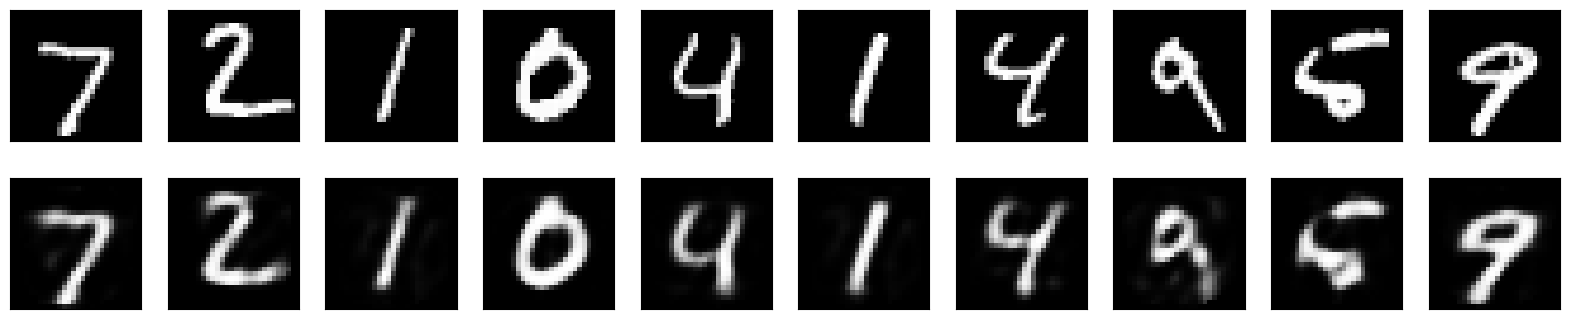

In [11]:
plot_imgs(x_test, decoded_s_imgs, n=10)

# **They look pretty similar to the previous model**
* ## Although a bit worse than the non sparse counterpart.
* ## But they are more prone to connection pruning
* ## Descreasing the regularization weight we can trade-off the sparsity and the reconstruction quality


--------------------------------------------

# **EXERCISE**
 * # Train a MLP to classify MNIST digits from the encoded representation
* # Compare the classification performance when using dense encoding and sparse encodings with different levels of sparsity
 * # Also evaluate the impact of the embedding dimension and loss on the performance  

----------------------------------------------------


# **Convolutional Autoencoders**
 * # Since our inputs are images, it makes sense to use convolutional neural networks as encoders and decoders
 * # Let's implement one. We need to redefine:
 1. # The ```conv_enc``` model a stack of ```Conv2D``` and ```MaxPooling2D``` layers
 > * ## the encoding dimension now is less immediate
 > * ## We need to compute it carefully according to the last convolutional and pooling layer
 2. # ```conv_dec``` model via a stack of ```Conv2D``` and ```UpSampling2D``` (or ```conv2DTranspose```) layers

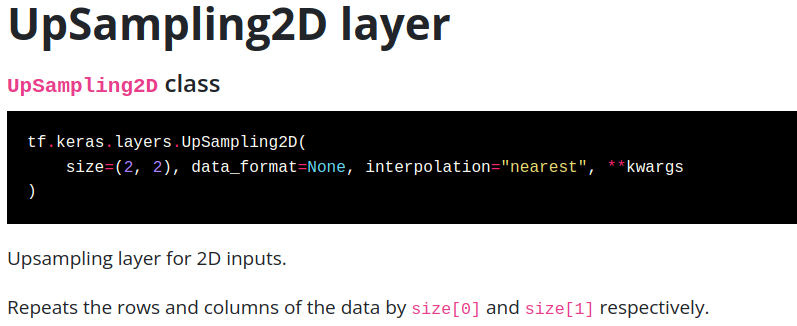

# Let's reshape input images
* ## For convolutional layers we need to add a third dimension to the input: the **number of input channels**

In [12]:
(x_train, _), (x_test, _) = mnist.load_data()
print(x_train.shape)
print(x_test.shape)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 28, 28, 1))
x_test = x_test.reshape((len(x_test), 28, 28, 1))
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [13]:
input_shape = tuple(x_train.shape[1:])

ENCODING_DIM = 32

# one Fully-Connected layer encoder
# ENCODING_DIM: This is the size of our encoded representations
def conv_enc(INPUT_SHAPE):
    model = K.Sequential([
#      input_img = layers.Input(shape=INPUT_SHAPE)
      layers.Conv2D(16, (3, 3), input_shape=INPUT_SHAPE,
                        activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      layers.Conv2D(2, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      # at this point the representation is (4, 4, 2)
      layers.Flatten()
    ])
    return model

# at this point the representation is 32-dimensional
def conv_dec(ENCODING_DIM, out_activation='sigmoid'):
  model = K.Sequential([
    layers.Reshape((4, 4, 2), input_shape=(ENCODING_DIM,)),
    layers.Conv2D(2, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation=out_activation,
                  padding='same')
  ])
  return model


class Conv_AE(K.Model):
  def __init__(self, INPUT_SHAPE, ENCODING_DIM,
               enc_model, dec_model, out_activation='sigmoid'):
    super(Conv_AE, self).__init__()
    #############################################
    #----------ENCODER--------------------------#
    # at this point the representation is (28,28,1)-dimensional
    self.encoder = enc_model(INPUT_SHAPE)
    # at this point the representation is 32-dimensional
    #############################################
    #----------DECODER--------------------------#
    self.decoder = dec_model(ENCODING_DIM, out_activation)

# method to encode images
  def getEncodedImage(self, image):
        encoded_image = self.encoder.predict(image)
        return encoded_image
# method to decode images
  def getDecodedImage(self, encoded_imgs):
      decoded_image = self.decoder.predict(encoded_imgs)
      return decoded_image

  def call(self, input):
    out_encoder = self.encoder(input)
    out_decoder = self.decoder(out_encoder)
    return out_decoder

autoenc_conv = Conv_AE(input_shape,
                    ENCODING_DIM,
                    conv_enc,
                    conv_dec,
                    out_activation='sigmoid')



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
autoenc_conv.encoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 2)        │           146 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466 (5.73 KB)

 Trainable params: 1,466 (5.73 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoenc_conv.decoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 4, 4, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 2)        │            38 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 8)        │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,503 (5.87 KB)

 Trainable params: 1,503 (5.87 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
lr = 2*10**-4
autoenc_conv.compile(optimizer=K.optimizers.Adam(learning_rate=lr),
                  loss='mse')
epochs = 50
batch_size=256
autoenc_conv.fit(x_train, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1690 - val_loss: 0.0786
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0705 - val_loss: 0.0584
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0567 - val_loss: 0.0530
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0524 - val_loss: 0.0502
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0500 - val_loss: 0.0484
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0483 - val_loss: 0.0471
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0471 - val_loss: 0.0459
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0460 - val_loss: 0.0449
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0450 - val_loss: 0.0439
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0441 - val_loss: 0.0431
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0432 - val_loss: 0.0425
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

# Being smaller then the first autoencoder we created above (around $50k$ versus $3k$), this model does not have accurate results

In [17]:
# Encode and decode test digits, then print some
encoded_conv_imgs = autoenc_conv.getEncodedImage(x_test)
print(encoded_conv_imgs[0:2])
decoded_conv_imgs = autoenc_conv.getDecodedImage(encoded_conv_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[0.01119008 4.267578   0.         5.732324   0.         5.721546
  0.         3.5695112  0.8948779  5.031047   0.         6.0422764
  0.         8.307381   0.         3.266715   0.37466773 2.038862
  0.         8.010906   0.         8.434656   0.         1.0124117
  0.14162368 2.6508017  0.46877152 6.256341   0.         2.423929
  0.03985364 0.741451  ]
 [0.         5.2703567  0.         8.103466   0.         6.8909593
  0.         1.0835598  0.6984726  4.2366114  0.         9.705322
  0.         7.403305   0.         1.6461468  0.         6.088973
  0.         8.79227    0.         7.3111143  0.         5.155343
  1.9942858  3.0514011  1.7420127  4.699812   0.2253407  3.8554437
  0.         1.6133515 ]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


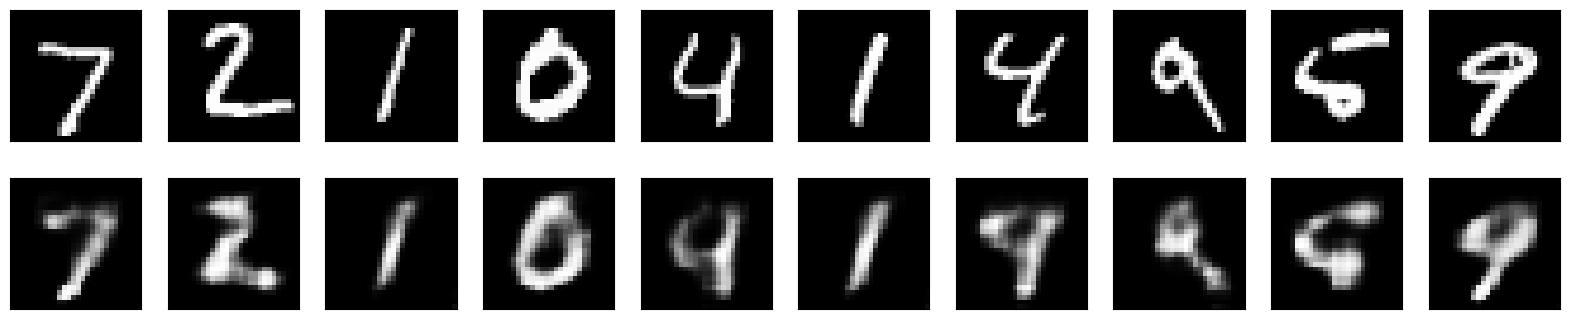

In [18]:
plot_imgs(x_test, decoded_conv_imgs, n=10)

# **Convolutional autoencoder for image denoising**
 * # We train the autoencoder to map noisy digits images into clean digits images
 * # We inject **noise** by setting to $0$ a given pixel with probability $p$, and leaving as is with probability $1-p$

In [19]:
# returns a MxN matrix with 0 in i,j-th entry with prob P
def randbin(M,N,P):
    return np.random.choice([0, 1], size=(M,N), p=[P, 1-P])

# Let's define a copy of our training and test data and add noise to them

In [20]:
x_train_noise = x_train.copy()
x_test_noise = x_test.copy()


In [21]:
M = x_train.shape[1]
N = x_train.shape[2]
p = 0.5
# setting to 0 the bits in the position where randMat is 0
for i in range(x_train_noise.shape[0]):
  randMat = randbin(M, N, p)
  x_train_noise[i][randMat == 0] = 0
for i in range(x_test_noise.shape[0]):
  randMat = randbin(M, N, p)
  x_test_noise[i][randMat == 0] = 0


# Visualize first $10$ training images with their noisy counterpart

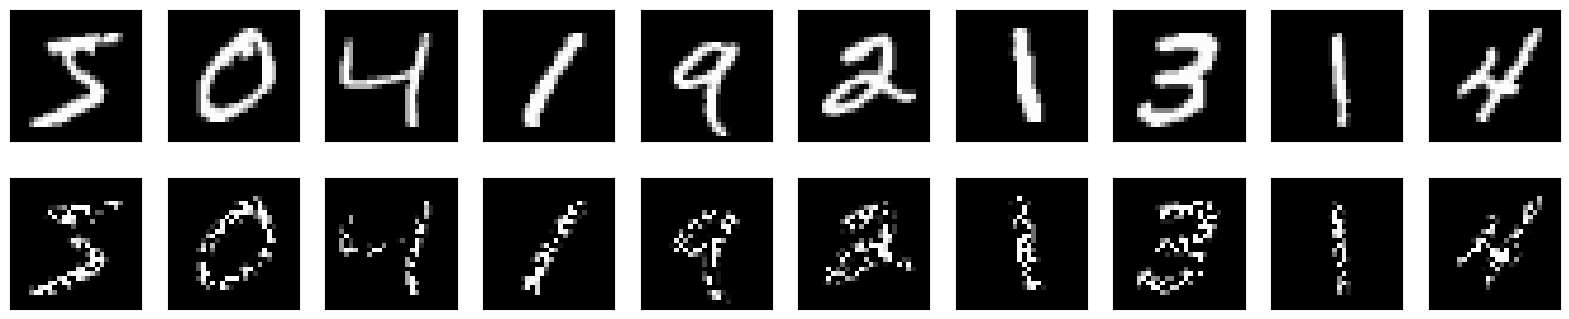

In [22]:
plot_imgs(x_train, x_train_noise, n=10)

# **Learning the autoencoder to denoise data**
 * # It takes as **input the noisy images**
 * # And **as output is the original images**!

In [23]:
autoenc_conv_noise = Conv_AE(input_shape,
                    ENCODING_DIM,
                    conv_enc,
                    conv_dec,
                    out_activation='sigmoid')

autoenc_conv_noise.compile(optimizer=K.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy')
epochs = 50
batch_size=256
autoenc_conv_noise.fit(x_train_noise, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test_noise, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.5872 - val_loss: 0.3413
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2995 - val_loss: 0.2417
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2373 - val_loss: 0.2283
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2264 - val_loss: 0.2203
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2189 - val_loss: 0.2140
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2136 - val_loss: 0.2093
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2089 - val_loss: 0.2051
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2050 - val_loss: 0.2019
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2020 - val_loss: 0.1991
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1994 - val_loss: 0.1967
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1970 - val_loss: 0.1917
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/ste

# Again, the training procedure it has likely not converged yet

In [24]:
# Encode and decode test digits, then print some
encoded_noise_imgs = autoenc_conv_noise.getEncodedImage(x_test_noise)
print(encoded_noise_imgs[0:2])
decoded_noise_imgs = autoenc_conv_noise.getDecodedImage(encoded_noise_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1.814641   4.724292   2.616791   7.19431    2.0583956  7.551471
  0.53953224 2.2139192  2.4359052  3.0688126  4.8485537  5.3275146
  5.5075626  7.7543087  2.4272165  1.11802    1.5508509  1.3015388
  4.286883   7.7561035  4.47099    6.263746   1.2530558  0.42715696
  1.1757524  0.79250467 4.480796   3.4260342  3.773518   0.23324499
  0.42870075 0.06126808]
 [2.0473683  3.7261043  6.1006274  7.8396115  5.2950044  5.6255193
  0.64280164 0.57042384 2.1904128  3.7785163  5.0632296  8.81689
  4.8255982  4.933382   0.8367753  2.134842   2.2942054  4.7634935
  6.1167436  8.88063    4.5922394  7.5465612  3.803313   4.9907856
  0.53414583 0.7578329  0.98060954 1.7446992  1.0609875  1.9167284
  1.0607044  0.93193114]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


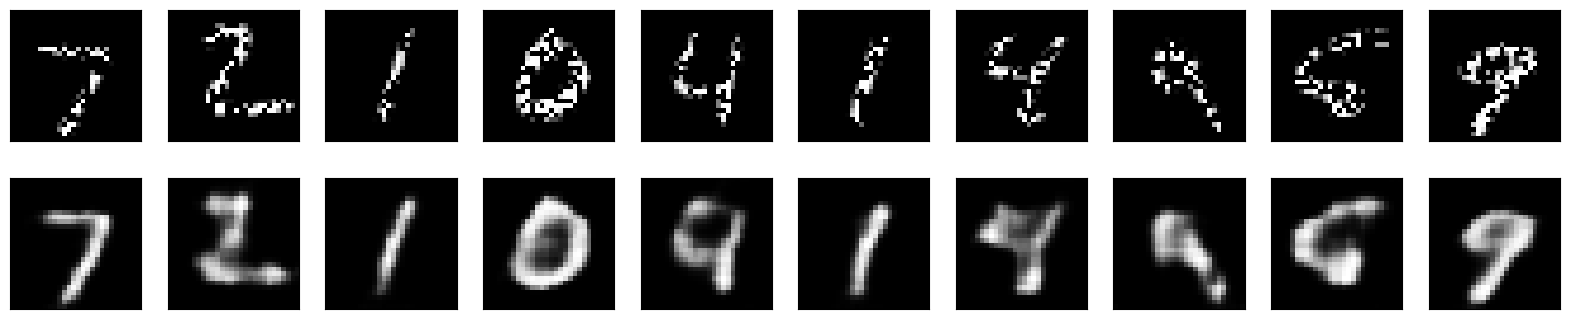

In [25]:
plot_imgs(x_test_noise, decoded_noise_imgs, n=10)

# The result, like before, are not exciting, the model is too small, but the noise we injected has been removed
* ## We need to increase the size
# Let's try with an **overcomplete AE**

In [26]:

ENCODING_DIM = 1024

# one Fully-Connected layer encoder
# ENCODING_DIM: This is the size of our encoded representations
def conv_enc(INPUT_SHAPE):
    model = K.Sequential([
#      input_img = layers.Input(shape=INPUT_SHAPE)
      layers.Conv2D(16, (3, 3), input_shape=INPUT_SHAPE,
                        activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2), padding='same'),
      # at this point the representation is (4, 4, 64)
      layers.Flatten()
    ])
    return model

# at this point the representation is 1024-dimensional
def conv_dec(ENCODING_DIM, out_activation='sigmoid'):
  model = K.Sequential([
    layers.Reshape((4, 4, 64), input_shape=(ENCODING_DIM,)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation=out_activation,
                  padding='same')
  ])
  return model

autoenc_conv_noise = Conv_AE(input_shape,
                    ENCODING_DIM,
                    conv_enc,
                    conv_dec,
                    out_activation='sigmoid')
autoenc_conv_noise.compile(optimizer=K.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy')
epochs = 50
batch_size=256
autoenc_conv_noise.fit(x_train_noise, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test_noise, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.4549 - val_loss: 0.1719
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1607 - val_loss: 0.1371
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1350 - val_loss: 0.1259
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1257 - val_loss: 0.1197
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1198 - val_loss: 0.1156
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1158 - val_loss: 0.1128
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1130 - val_loss: 0.1098
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1104 - val_loss: 0.1078
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1082 - val_loss: 0.1058
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1066 - val_loss: 0.1045
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1050 - val_loss: 0.1030
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

(10000, 28, 28, 1)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1.7758884  1.4319072  1.4243156  ... 0.         0.18143447 0.01009099]
 [1.3524202  1.3700708  1.2290616  ... 0.71983945 0.13567813 0.11267985]]
(10000, 1024)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


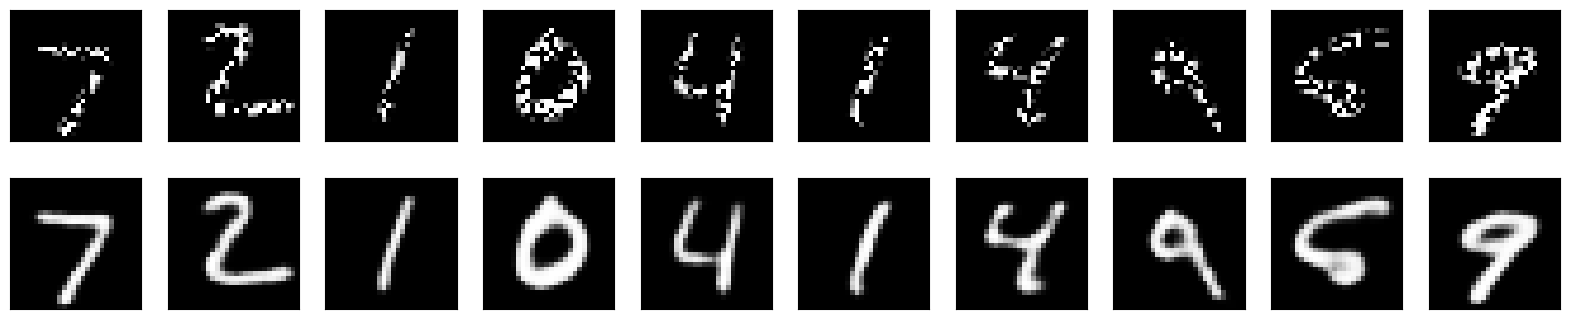

In [27]:
print(x_test_noise.shape)
# Encode and decode test digits, then print some
encoded_noise_imgs = autoenc_conv_noise.getEncodedImage(x_test_noise)
print(encoded_noise_imgs[0:2])
print(encoded_noise_imgs.shape)
decoded_noise_imgs = autoenc_conv_noise.getDecodedImage(encoded_noise_imgs)
plot_imgs(x_test_noise, decoded_noise_imgs, n=10)

# **Now the result is much better!!**